## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np 
import json
import importlib
import matplotlib.pyplot as plt

from pathlib import Path

import src.statistics.spline as spline

In [22]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]


scale_cut = [1, 5]  # in Mpc/h
with open(f"merged_bins_sc_{scale_cut[0]}_{scale_cut[1]}.json", "r") as f:
    data = json.load(f)

In [23]:
importlib.reload(spline)
save_splines = Path('splines') / f'photoz_bias_splines_v3_dz01_sc_{scale_cut[0]}_{scale_cut[1]}'
save_splines.mkdir(exist_ok=True)
cmap = plt.get_cmap('magma_r')

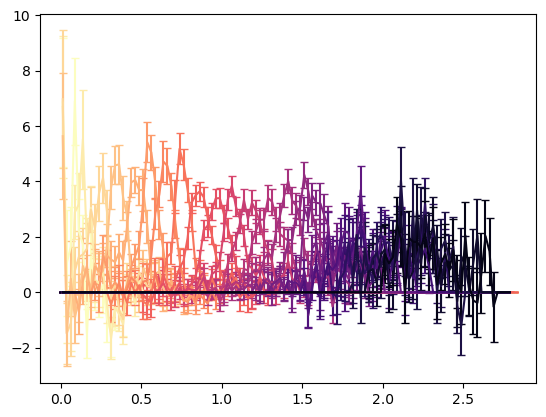

In [24]:
for tomo in data.keys():
    outbase = save_splines / f'spline_tomo{tomo}'
    plt.errorbar(data[tomo][0], data[tomo][1], data[tomo][2], label=f'Tomo {tomo}', capsize=3, color=cmap((int(tomo)-1)/len(list(data.keys()))))

In [25]:
for tomo in data.keys():
    outbase = save_splines / f'spline_tomo{tomo}'
    if outbase.with_suffix('.nc').exists():
        continue
    arr = data[tomo][2].copy()
    data[tomo][1][0] = 0
    data[tomo][2][0] = 0
    spl = spline.BayesianBSpline(zv=np.array(data[tomo][0]), n_knots=len(np.array(data[tomo][0])) // 2)
    spl.fit(np.array(data[tomo][1]), np.array(data[tomo][2]), target_accept=0.99, n_samples=800, n_tune=300, prior_concentration=3, base_alpha=0.05)
    spl.save_model(filename_base=outbase)

8.975456894285026
Dirichlet alpha range: [0.050, 16.046]
Non-zero NNLS coefficients: 3 / 58
[0.         0.         5.33186609 3.18910261 0.         0.45448819
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 300 tune and 800 draw iterations (1_200 + 3_200 draws total) took 111 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Model fitting complete. Summary:              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]   0.002  0.007   0.000    0.007      0.000    0.000     723.0   
coeffs[1]   0.002  0.007   0.000    0.007      0.000    0.001     619.0   
coeffs[2]   0.555  0.082   0.400    0.701      0.001    0.001    3226.0   
coeffs[3]   0.307  0.076   0.167    0.446      0.001    0.001    2987.0   
coeffs[4]   0.001  0.005   0.000    0.005      0.000    0.000     869.0   
coeffs[5]   0.046  0.034   0.001    0.108      0.001    0.001    2892.0   
coeffs[6]   0.001  0.006   0.000    0.005      0.000    0.001     779.0   
coeffs[7]   0.001  0.004   0.000    0.003      0.000    0.000     901.0   
coeffs[8]   0.001  0.005   0.000    0.003      0.000    0.000     886.0   
coeffs[9]   0.002  0.007   0.000    0.008      0.000    0.001     930.0   
coeffs[10]  0.002  0.007   0.000    0.008      0.000    0.000    1031.0   
coeffs[11]  0.002  0.007   0.000    0.006      0.000    0.001     9

...

Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.001  0.004   0.000    0.004      0.000    0.000     665.0   
coeffs[1]    0.001  0.004   0.000    0.004      0.000    0.000     722.0   
coeffs[2]    0.001  0.004   0.000    0.005      0.000    0.000    1015.0   
coeffs[3]    0.001  0.004   0.000    0.004      0.000    0.000     860.0   
coeffs[4]    0.001  0.005   0.000    0.005      0.000    0.000    1082.0   
coeffs[5]    0.001  0.004   0.000    0.003      0.000    0.000     759.0   
coeffs[6]    0.001  0.004   0.000    0.004      0.000    0.000     935.0   
coeffs[7]    0.001  0.004   0.000    0.004      0.000    0.000     800.0   
coeffs[8]    0.001  0.004   0.000    0.004      0.000    0.000     766.0   
coeffs[9]    0.001  0.004   0.000    0.005      0.000    0.000     813.0   
coeffs[10]   0.001  0.004   0.000    0.005      0.000    0.000    1020.0   
coeffs[11]   0.001  0.005   0.000    0.004      0.000  

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 300 tune and 800 draw iterations (1_200 + 3_200 draws total) took 69 seconds.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.001  0.004   0.000    0.004      0.000    0.000     788.0   
coeffs[1]    0.001  0.004   0.000    0.004      0.000    0.000     843.0   
coeffs[2]    0.001  0.005   0.000    0.004      0.000    0.001     959.0   
coeffs[3]    0.001  0.005   0.000    0.004      0.000    0.000     796.0   
coeffs[4]    0.001  0.004   0.000    0.003      0.000    0.000    1116.0   
coeffs[5]    0.001  0.005   0.000    0.004      0.000    0.000     647.0   
coeffs[6]    0.001  0.004   0.000    0.004      0.000    0.000     788.0   
coeffs[7]    0.001  0.004   0.000    0.004      0.000    0.000    1256.0   
coeffs[8]    0.001  0.004   0.000    0.004      0.000    0.000     787.0   
coeffs[9]    0.001  0.004   0.000    0.004      0.000    0.000     957.0   
coeffs[10]   0.001  0.005   0.000    0.004      0.000    0.000     855.0   
coeffs[11]   0.001  0.004   0.000    0.004      0.000  

In [ ]:
spl.plot_fit()
np.median(spl.coeffs_samples, axis=0)

In [26]:
## now register the n(z) distributions for every sample
tomo_dict = {}
for tomo in data.keys():
    spl = spline.BayesianBSpline.from_saved_model(filename_base=save_splines / f'spline_tomo{tomo}')
    z_eval = np.linspace(0., 3.0, 200)
    results = spl.get_spline_from_trace(z_eval=z_eval)
    bin_center = -0.05+int(tomo)*0.1
    mask = (z_eval >= bin_center - 0.1 * 5) & (z_eval <= bin_center + 0.1 * 5)
    redshifts = z_eval[mask]
    nz_lower = results['nz_lower'][mask]
    nz_upper = results['nz_upper'][mask]
    nz_median = results['nz_median'][mask]
    integral = np.trapezoid(nz_median, redshifts)
    print(integral)
    nz_lower_n = nz_lower #/ integral
    nz_upper_n = nz_upper #/ integral
    nz_median_n = nz_median #/ integral

    tomo_dict[tomo] = {
        'redshifts': redshifts,
        'nz_lower': nz_lower_n,
        'nz_upper': nz_upper_n,
        'nz_median': nz_median_n
    }
tomo_dict_flattened = {f'{t}/{k}': v for t, d in tomo_dict.items() for k, v in d.items()}
print(tomo_dict_flattened)
# save to a numpy array
np.savez_compressed(save_splines / f'tomo_photoz.npz', **tomo_dict_flattened)

8.975456894285026
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo1.nc
  - Metadata: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo1_meta.pkl
  - Posterior samples: 3200
0.3448614157547464
8.902022725750145
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo2.nc
  - Metadata: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo2_meta.pkl
  - Posterior samples: 3200
0.41004695780573147
11.816592047724429
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo3.nc
  - Metadata: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo3_meta.pkl
  - Posterior samples: 3200
0.5695389682829244
14.199235179132273
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines/photoz_bias_splines_v3_dz01_sc_1_5/spline_tomo4.nc
  - Metadata: splines/photoz_bias_splines_v

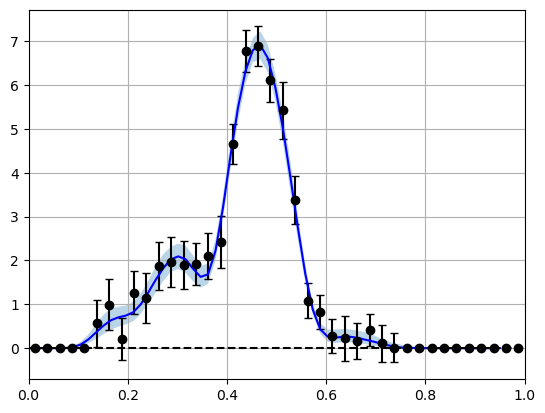

In [19]:
bin_show = 5
for t in data.keys():
    if int(t) != bin_show:
        continue
    plt.fill_between(x=np.array(tomo_dict[t]['redshifts']),
                     y1=np.array(tomo_dict[t]['nz_lower']),
                     y2=np.array(tomo_dict[t]['nz_upper']),
                     alpha=0.3)
    plt.errorbar(
        data[t][0], data[t][1], yerr=data[t][2], capsize=3, fmt='o', color='black'
    )
    plt.xlim((bin_show-5)*0.1, (bin_show+5)*0.1)
    plt.plot(np.array(tomo_dict[t]['redshifts']), np.array(tomo_dict[t]['nz_median']), color='blue')
    plt.axhline(0, color='k', linestyle='--')
plt.grid(True)

In [20]:
nz_samples = (spl.coeffs_samples @ spl._create_evaluation_basis(np.array(data[tomo][0])).T) * spl.amplitude_samples[:, np.newaxis]
nz_median = np.percentile(nz_samples, 50, axis=0)
print(nz_median)

[1.99423974e-07 8.52573099e-04 5.16732420e-04 7.66500555e-04
 5.66466969e-04 6.55040078e-04 5.29318045e-04 7.13983380e-04
 6.49788465e-04 8.42344603e-04 5.35213358e-04 6.11327937e-04
 4.58130366e-04 6.27474681e-04 5.21511767e-04 7.21170685e-04
 6.42270236e-04 6.93613974e-04 4.76152852e-04 7.23884395e-04
 5.19694457e-04 6.28661638e-04 4.29591034e-04 5.96581393e-04
 5.00980174e-04 6.72272167e-04 5.64179827e-04 7.54089180e-04
 6.23562399e-04 7.64368075e-04 7.13550935e-04 8.35721249e-04
 7.50645745e-04 8.86747168e-04 6.24339384e-04 6.64833416e-04
 4.96408237e-04 5.67224127e-04 5.11844227e-04 6.36956792e-04
 4.82957698e-04 5.47104489e-04 4.95160218e-04 5.71903048e-04
 5.15702948e-04 5.43638098e-04 5.39423179e-04 5.95119285e-04
 5.15881163e-04 5.49741624e-04 6.15156555e-04 6.64023689e-04
 6.60578050e-04 7.07281438e-04 6.50642744e-04 5.79884787e-04
 6.07672664e-04 5.69870694e-04 5.82069378e-04 6.37764663e-04
 6.27770446e-04 6.40110821e-04 6.99073487e-04 6.88605154e-04
 8.00411329e-04 7.424907

/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/spline.py:685: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 900x800 with 3 Axes>,
 (<Axes: xlabel='Redshift (z)', ylabel='n(z)'>,
  <Axes: title={'center': 'B-spline Basis Functions (showing 58/58)'}, xlabel='Redshift (z)', ylabel='Basis amplitude'>,
  <Axes: title={'center': 'Posterior Coefficient Distribution'}, xlabel='Basis Function Index', ylabel='Coefficient Value'>))

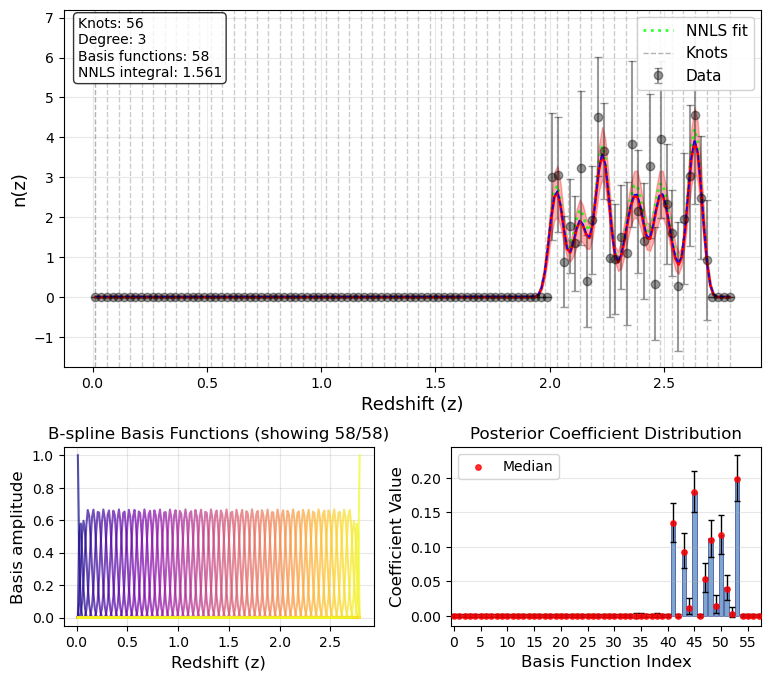

In [21]:
spl.plot_fit()